<a href="https://colab.research.google.com/github/Erwin2Sibaja/challenge_2_telecom_x/blob/main/Telecom_X_An%C3%A1lisis_de_Evasi%C3%B3n_de_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

In [57]:
clientes = pd.read_json('/content/drive/MyDrive/Colab Notebooks/Challenge 2/TelecomX_Data.json')
clientes

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## Diccionario e datos

*   **customerID**: número de identificación único de cada cliente
*   **Churn**: si el cliente dejó o no la empresa
*   **gender**: género (masculino y femenino)
*   **SeniorCitizen**: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
*   **Partner**: si el cliente tiene o no una pareja
*   **Dependents**: si el cliente tiene o no dependientes
*   **tenure**: meses de contrato del cliente
*   **PhoneService**: suscripción al servicio telefónico
*   **MultipleLines**: suscripción a más de una línea telefónica
*   **InternetService**: suscripción a un proveedor de internet
*   **OnlineSecurity**: suscripción adicional de seguridad en línea
*   **OnlineBackup**: suscripción adicional de respaldo en línea
*   **DeviceProtection**: suscripción adicional de protección del dispositivo
*   **TechSupport**: suscripción adicional de soporte técnico, menor tiempo de espera

*   **StreamingTV**: suscripción de televisión por cable
*   **StreamingMovies**: suscripción de streaming de películas
*   **Contract**: tipo de contrato
*   **PaperlessBilling**: si el cliente prefiere recibir la factura en línea
*   **PaymentMethod**: forma de pago
*   **Charges.Monthly**: total de todos los servicios del cliente por mes
*   **Charges.Total**: total gastado por el cliente

# Transformación

In [58]:
print(clientes['customer'].iloc[0])
print(clientes['phone'].iloc[0])
print(clientes['internet'].iloc[0])
print(clientes['account'].iloc[0])

{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}
{'PhoneService': 'Yes', 'MultipleLines': 'No'}
{'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}
{'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}


In [59]:
columnas_dict = ['customer', 'phone', 'internet', 'account']

for col in columnas_dict:
    clientes[col] = clientes[col].apply(lambda x: x if isinstance(x, dict) else {})

In [60]:
df_customer = pd.json_normalize(clientes['customer'])
df_phone = pd.json_normalize(clientes['phone'])
df_internet = pd.json_normalize(clientes['internet'])

df_account = pd.json_normalize(clientes['account'])

clientes_final = pd.concat([
    clientes.drop(columns=columnas_dict),
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)


clientes_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [61]:
clientes_final['Charges.Total'] = pd.to_numeric(clientes_final['Charges.Total'], errors='coerce')
clientes_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [62]:
clientes_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#Carga y análisis

In [63]:
for col in clientes_final.select_dtypes(include='object').columns:
    print(f"Columna: {col}")
    print(clientes_final[col].unique())
    print("-" * 20)

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------
Columna: Churn
['No' 'Yes' '']
--------------------
Columna: gender
['Female' 'Male']
--------------------
Columna: Partner
['Yes' 'No']
--------------------
Columna: Dependents
['Yes' 'No']
--------------------
Columna: PhoneService
['Yes' 'No']
--------------------
Columna: MultipleLines
['No' 'Yes' 'No phone service']
--------------------
Columna: InternetService
['DSL' 'Fiber optic' 'No']
--------------------
Columna: OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------
Columna: OnlineBackup
['Yes' 'No' 'No internet service']
--------------------
Columna: DeviceProtection
['No' 'Yes' 'No internet service']
--------------------
Columna: TechSupport
['Yes' 'No' 'No internet service']
--------------------
Columna: StreamingTV
['Yes' 'No' 'No internet service']
--------------------
Columna: StreamingMovies
['No' 'Yes' 'No internet service']
---

In [64]:
clientes_final['Churn'] = clientes_final['Churn'].replace('', pd.NA)
columnas_a_limpiar = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in columnas_a_limpiar:
    clientes_final[col] = clientes_final[col].replace({
        'No phone service': 'No',
        'No internet service': 'No'
    })

for col in columnas_a_limpiar + ['Churn']:
    print(f"{col}: {clientes_final[col].unique()}")

MultipleLines: ['No' 'Yes']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['Yes' 'No']
StreamingTV: ['Yes' 'No']
StreamingMovies: ['No' 'Yes']
Churn: ['No' 'Yes' <NA>]


In [65]:
cols_dinero = ['Charges.Monthly', 'Charges.Total']

for col in cols_dinero:
    if col in clientes_final.columns:
        clientes_final[col] = clientes_final[col].astype(str).str.replace(',', '.')
        clientes_final[col] = pd.to_numeric(clientes_final[col], errors='coerce')

clientes_final[cols_dinero] = clientes_final[cols_dinero].fillna(clientes_final[cols_dinero].median())

In [66]:
clientes_final['Cuentas_Diarias'] = (clientes_final['Charges.Monthly'] / 30).round(2)
clientes_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [67]:
mapeo = {'Yes': '1', 'No': '0'}
columnas_a_mapear = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

for col in columnas_a_mapear:
  if col in clientes_final.columns:
    clientes_final[col] = clientes_final[col].map(mapeo)
#Si es requerido cambiar el valor NA que esta en Churn
## clientes_final['Churn'] = clientes_final['Churn'].fillna(0)

clientes_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.26


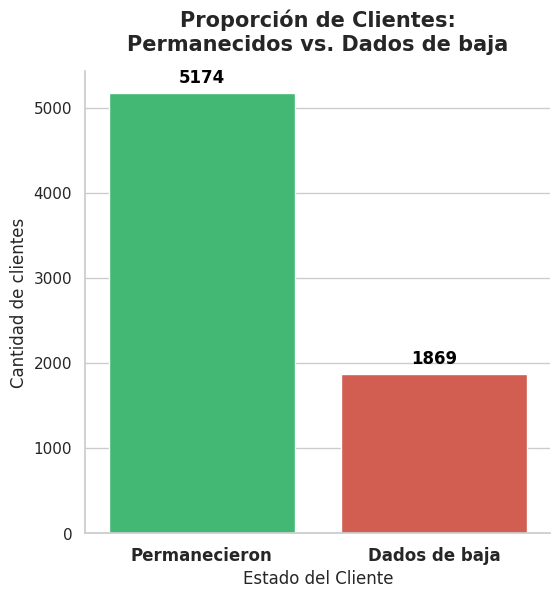

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,6))

ax = sns.countplot(
    data=clientes_final.dropna(subset=['Churn']),
    x='Churn',
    hue='Churn',
    palette=['#2ecc71', '#e74c3c'],
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Permanecieron', 'Dados de baja'], fontsize=12, fontweight='bold')
plt.title('Proporción de Clientes:\nPermanecidos vs. Dados de baja', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

sns.despine()

plt.show()

In [51]:
clientes_final['Churn_Num'] = pd.to_numeric(clientes_final['Churn'], errors='coerce')

variables_estrategicas = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'gender']
cols_existentes = [col for col in variables_estrategicas if col in clientes_final.columns]

df_unificado = clientes_final.dropna(subset=['Churn_Num']).melt(
    id_vars=['Churn_Num'],
    value_vars=cols_existentes,
    var_name='Categoria_Principal',
    value_name='Opcion'
)

df_unificado['Opcion'] = df_unificado['Opcion'].astype(str)
df_unificado['Etiqueta'] = df_unificado['Categoria_Principal'] + ' - ' + df_unificado['Opcion']

resumen = df_unificado.groupby('Etiqueta').agg(
    Total_Clientes=('Churn_Num', 'count'),
    Fugas=('Churn_Num', 'sum')
).reset_index()

resumen['Tasa_Fuga_%'] = (resumen['Fugas'] / resumen['Total_Clientes'] * 100).round(1)

resumen = resumen.sort_values('Tasa_Fuga_%', ascending=True)

fig = px.bar(
    resumen,
    x='Tasa_Fuga_%',
    y='Etiqueta',
    orientation='h',
    text='Tasa_Fuga_%',
    color='Tasa_Fuga_%',
    color_continuous_scale='Reds',
    title='Ranking de Riesgo: Tasa de Abandono por Perfil de Cliente',
    labels={'Tasa_Fuga_%': 'Tasa de abandono (%)', 'Etiqueta': 'Perfil del Cliente'}
)

fig.update_traces(
    texttemplate='%{text}%',
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>Tasa Abandono: %{x}%<br>Total Clientes en este perfil: %{customdata[0]}<br>Clientes Perdidos: %{customdata[1]}<extra></extra>",
    customdata=resumen[['Total_Clientes', 'Fugas']]
)

fig.update_layout(
    height=700,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(showgrid=True, gridcolor='lightgray', range=[0, max(resumen['Tasa_Fuga_%']) + 15]),
    coloraxis_showscale=False
)

fig.show()

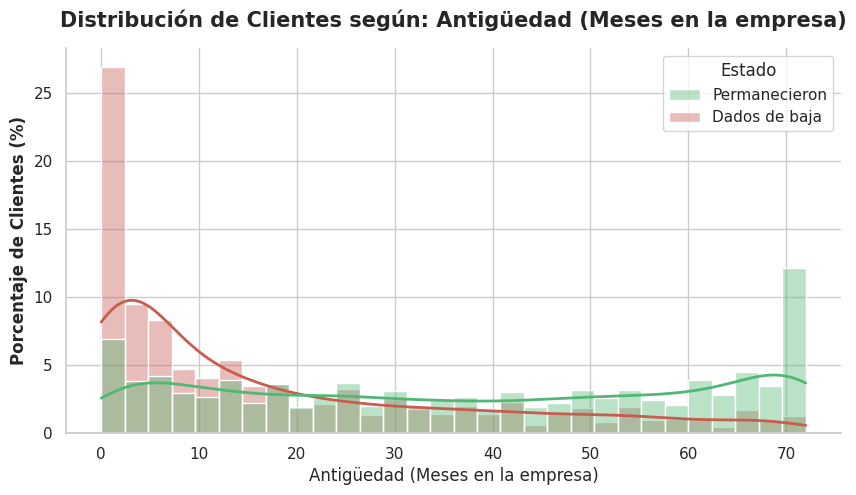

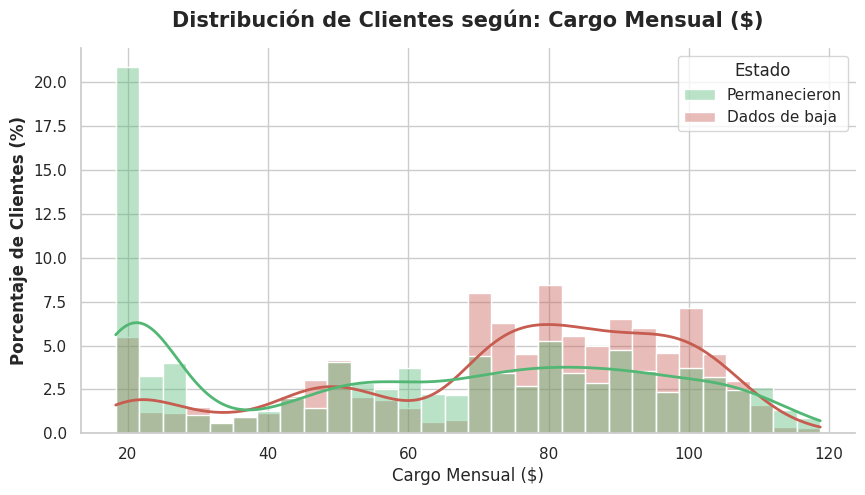

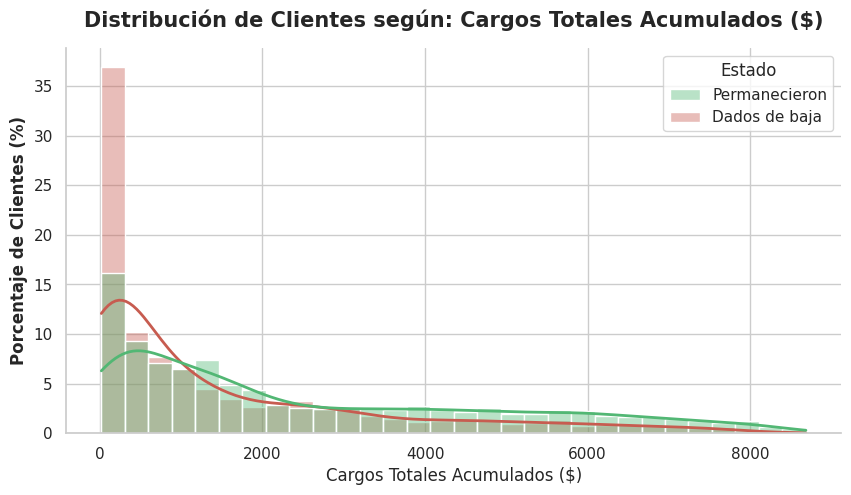

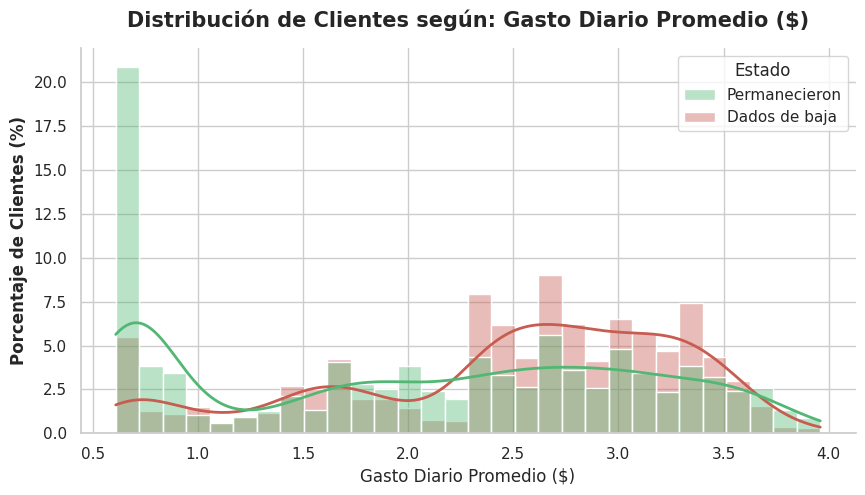

In [71]:
df_num = clientes_final.copy()
df_num['Churn_Num'] = pd.to_numeric(df_num['Churn'], errors='coerce')
df_num['Estado'] = df_num['Churn_Num'].map({0: 'Permanecieron', 1: 'Dados de baja'})
df_num = df_num.dropna(subset=['Estado'])

variables = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
nombres_eje_x = [
    'Antigüedad (Meses en la empresa)',
    'Cargo Mensual ($)',
    'Cargos Totales Acumulados ($)',
    'Gasto Diario Promedio ($)'
]

sns.set_theme(style="whitegrid")
colores = {'Permanecieron': '#52b774', 'Dados de baja': '#c75c50'}

for col, nombre_x in zip(variables, nombres_eje_x):
    if col in df_num.columns:
        df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

        plt.figure(figsize=(10, 5))

        sns.histplot(
            data=df_num,
            x=col,
            hue='Estado',
            stat='percent',
            common_norm=False,
            palette=colores,
            alpha=0.4,
            kde=True,
            bins=30,
            line_kws={'linewidth': 2}
        )

        plt.title(f'Distribución de Clientes según: {nombre_x}', fontsize=15, fontweight='bold', pad=15)
        plt.xlabel(nombre_x, fontsize=12)
        plt.ylabel('Porcentaje de Clientes (%)', fontsize=12, fontweight='bold')

        sns.despine()

        plt.show()

# Informe final

##1.- Introducción

El propósito de este análisis fue meternos de lleno a los datos para entender un problema que a toda empresa le quita el sueño: el Churn o abandono de clientes.

Al final del día, perder a un usuario no solo es una suscripción menos, sino que financieramente nos sale mucho más caro salir a buscar clientes nuevos que cuidar a los que ya confiaron en nosotros. Con este proyecto buscamos dejar de adivinar o actuar por intuición, y en su lugar, dejar que los datos nos cuenten la historia exacta de por qué la gente cancela su servicio para poder tomar cartas en el asunto.

##2.- Limpieza y tratamiento de datos

Antes de poder hacer gráficos y sacar conclusiones, tuvimos que organizar la información. Los datos originales venían en un formato JSON que dificulta su interpretación e imposibilita analizar los datos a simple vista, por medio de los siguientes puntos logramos realizar un mejor analisis de los datos:.

*   Usamos Python (Pandas) para "aplanar" esa información anidada y armar una tabla limpia y fácil de leer.
*   Juntamos los "Sin servicio" con los "No" simples y arreglamos problemas de formato numérico, como los números que venían con comas en lugar de puntos.
*   Convertimos las respuestas de texto ("Sí" y "No") en números ("1" y "0") para poder hacer cálculos matemáticos reales.
*   Creamos una nueva columna para ver el gasto diario de cada cliente, dándonos una idea más clara del valor que aporta cada persona en el día a día.

##3.- Análisis exploratorio

Una vez que todo quedo limpio empezamos a crear graficos para interpretar y exponer los requerimientos que se solicitaron para el comportamiento de clientes. Comparamos el abandono contra cosas como el tipo de contrato que tenían, cómo pagaban, qué tipo de internet usaban y cuánto tiempo llevaban con la empresa. Además, usamos gráficos de distribución (las gráficas de "montaña") para ver en qué momento exacto del tiempo o en qué nivel de precios ocurrían más cancelaciones.


##4.- Conclusiones:

Los datos nos revelaron varios "focos rojos" súper interesantes que explican gran parte del problema:

*   Vimos claramente que la mayoría de los clientes que deciden irse, lo hacen al principio. Si logramos que un cliente supere los primeros meses, es muy probable que se vuelva leal a largo plazo
*   Los clientes con contratos mensuales son, por mucho, los que más cancelan. Tener que decidir cada 30 días si vale la pena seguir pagando genera demasiada fricción.
*   Notamos picos de abandono inusuales en los usuarios que tienen internet por Fibra Óptica y en aquellos que pagan mediante Cheque Electrónico. Esto nos grita que ahí hay un problema de servicio o de proceso.
*   El impacto del soporte técnico: Quienes no tienen contratado el soporte técnico se van a la primera falla. Básicamente, se frustran y cancelan.

##5.- Recomendaciones

Basados en todo lo que vimos, aquí van unas sugerencias claras para empezar a tapar estas fugas de clientes:

*   Necesitamos diseñar campañas o promociones agresivas para convencer a la gente del plan mensual de que se pase a un contrato anual. (Ejemplo: "Cámbiate al plan anual y te regalamos dos meses o mejoramos tu velocidad").
*   Sugiero implementar un programa de onboarding fuerte. Si sabemos que la gente se va al principio, el equipo de atención debe estar súper cerca de ellos sus primeros 90 días para asegurar que todo funcione perfecto.
*   Hay que revisar con el equipo técnico para preguntarles: "¿Qué está pasando con la Fibra Óptica? ¿Se cae mucho?". Y con finanzas: "¿El cheque electrónico es muy difícil de procesar para el cliente?".
*   Valdría la pena considerar ofrecer el soporte técnico de manera gratuita o a un costo casi nulo como beneficio estándar, ya que retiene a muchísimos clientes.
